In [1]:
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters

%matplotlib inline

In [2]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.ryy(0, 1, p[0] * x[0])

In [3]:
p_obs = Parameters("p_obs", 2)
observable = QuantumOperator(["ZI", "IZ"], [p_obs[0], p_obs[1]])

SparsePauliOp(['ZI', 'IZ'],
              coeffs=[<qiskit._accelerate.circuit.ParameterExpression object at 0x000001B5FAE36EB0>,
 <qiskit._accelerate.circuit.ParameterExpression object at 0x000001B5FAE373F0>])


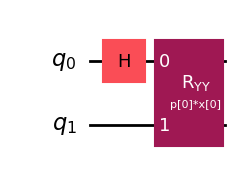

In [4]:
executor = Executor.create("qiskit", seed=0, shots=10000)

qiskit_circuit = executor.transpile_circuit(qc)
qiskit_circuit.qiskit_circuit.draw("mpl")

qiskit_observable = executor.transpile_operator(observable)
print(qiskit_observable.qiskit_operator)

In [5]:
result = executor.expectation_value(
    qiskit_circuit,
    qiskit_observable,
    x=[0.1],
    p=[0.3],
    p_obs=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.482763671875


In [6]:
v = executor.expectation_value_derivatives(
    qiskit_circuit,
    qiskit_observable,
    "x",
    "p",
    "p_obs",
    x=[0.1],
    p=[0.3],
    p_obs=[0.5, 0.6],
)
print(v)

{'x': array([0.00236572]), 'p': array([-0.00122314]), 'p_obs': array([[0.99951172],
       [0.00292969]])}


In [7]:
executor.statevector(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

array([0.69301172+0.j        , 0.        -0.14048043j,
       0.69301172+0.j        , 0.        +0.14048043j])

In [8]:
executor.sample(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

{'10': 4875, '00': 4713, '01': 204, '11': 208}